In [215]:
%load_ext autoreload
%autoreload 2

import os,sys
import torch
import yaml
import numpy as np
import pandas as pd 

from torch import nn
from torchdiffeq import odeint

from PINN import models
import matplotlib.pyplot as plt

import umap
import phate

from scipy.stats import gaussian_kde

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import anndata as ad

In [3]:
import scanpy as sc

In [4]:
sc.set_figure_params(figsize=(4,4), dpi=80, frameon=False)

In [5]:
import umap
import phate

# reload synthesized data
convert to adata

In [6]:
syn_result_ckpt = torch.load("data/synthesized_data/5Dim_ncs_synparam_Jan23/syn_result_0-4.ckpt")
density = syn_result_ckpt['u_simulate']
integrate_time = syn_result_ckpt['integrate_time']
ds = syn_result_ckpt['delta_x']

convert to adata

# load model

In [212]:
syn_ad = sc.read_h5ad("data/synthesized_data/5Dim_ncs_synparam_Jan23/syn_cell_0_4.h5ad")
cellstate = torch.from_numpy(syn_ad.X).float()
timepoint_input = torch.from_numpy(syn_ad.obs.time.values).float()
syn_ad

AnnData object with n_obs × n_vars = 22000 × 5
    obs: 'time', 'source', 'timepoint', 'leiden', 'leiden_rs0.1'
    uns: 'leiden', 'leiden_colors', 'leiden_rs0.1', 'leiden_rs0.1_colors', 'neighbors', 'pop'
    obsm: 'Delta_DM', 'X_data', 'X_phate', 'X_umap'
    obsp: 'connectivities', 'distances'

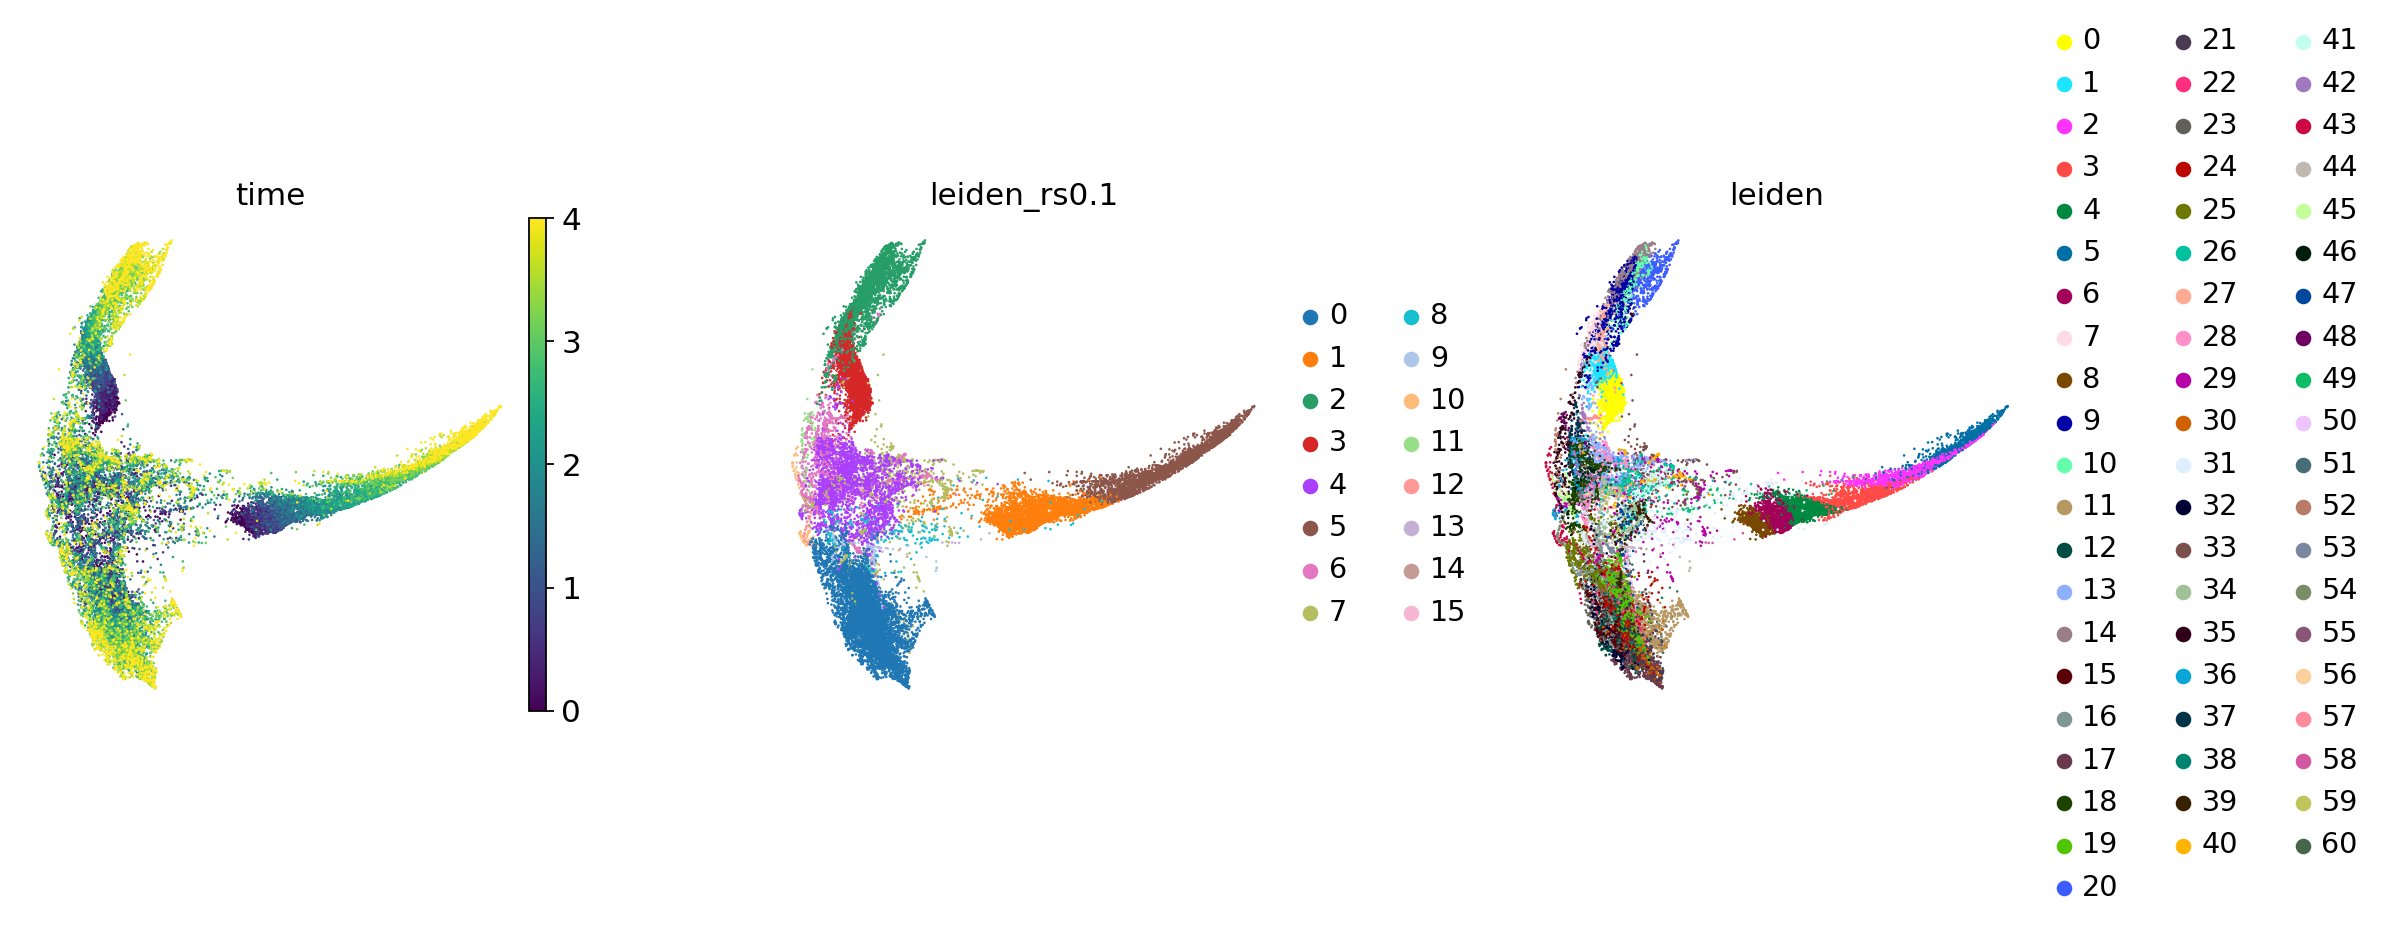

In [9]:
sc.pl.umap(syn_ad,  color=['time', 'leiden_rs0.1', 'leiden'], wspace=0.35)

In [107]:
import PINN

In [116]:
syn_ad.uns['pop']['t'] = np.around(integrate_time.numpy(), 1)

In [117]:
syn_ad.uns['pop']['t']

array([0. , 0.4, 0.8, 1.2, 1.6, 2. , 2.4, 2.8, 3.2, 3.6, 4. ],
      dtype=float32)

In [192]:
density.sum(axis=1)

tensor([1.0000e+00, 1.3450e+00, 1.7022e+00, 1.9618e+00, 2.3858e+00, 3.6628e+00,
        7.8288e+00, 2.7318e+01, 1.2542e+02, 6.5866e+02, 3.6998e+03])

prediction of shape (11, 22000)


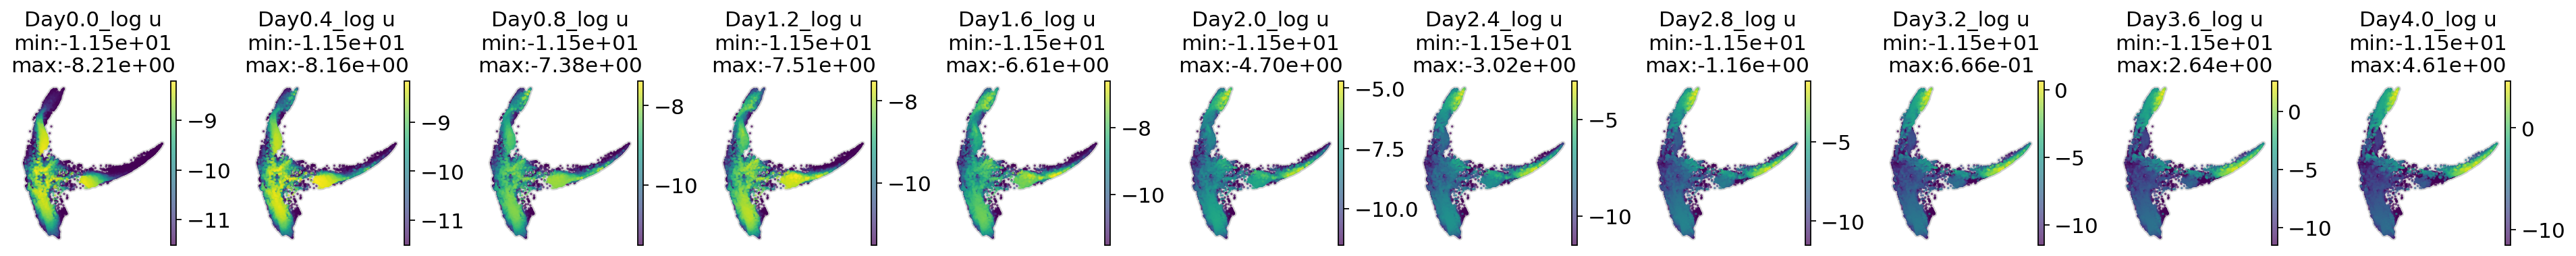

In [214]:
log_u = np.log(density.numpy()+1e-5)
PINN.pl.params_in_umap(syn_ad, log_u, param='log u', timepoints=np.around(integrate_time.numpy(), 1).astype(str), cell_of_t=False, umap_kws={"s":10});

In [10]:
spline_knots = torch.load("data/synthesized_data/5Dim_ncs_synparam_Jan23/biomodal_g_norm_D_params_0_4.ckpt")

v_spline = models.MultiDim_CubicSpline(y=spline_knots['v'].T, x=spline_knots['x'].T)
g_spline = models.MultiDim_CubicSpline(y=spline_knots['g'].T, x=spline_knots['x'].T, collapse=True)
D_spline = models.MultiDim_CubicSpline(y=spline_knots['D'].T, x=spline_knots['x'].T, collapse=True)

/ssd/users/Wergillius/Project/PINN_dynamics/PINN/models/Spline_models.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("x", torch.tensor(x, dtype=torch.float32, requires_grad=False))


In [276]:
with torch.no_grad():
    v_true = v_spline(cellstate, None).cpu().numpy()
    g_true = g_spline(cellstate, None).cpu().numpy().flatten()
    D_true = D_spline(cellstate, None).cpu().numpy().flatten()

syn_ad.obs['g_true'] = g_true
syn_ad.obs['D_true'] = D_true
syn_ad.obsm['v_true'] = v_true
syn_ad.layers['v_true'] = v_true

In [29]:
syn_ad.obs.query("`g_true` > 3").leiden.value_counts()

leiden
5     720
2     623
3     289
4      81
26     56
     ... 
25      0
27      0
1       0
32      0
60      0
Name: count, Length: 61, dtype: int64

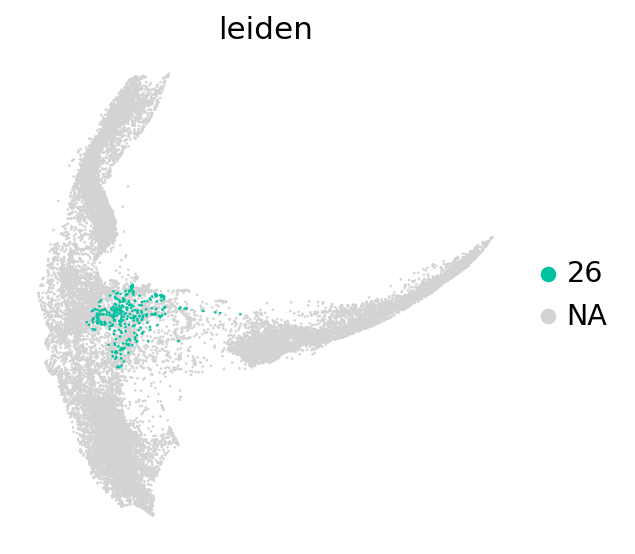

In [31]:
sc.pl.umap(syn_ad, color='leiden', groups=['26'])

In [123]:
all_ad = syn_ad.copy()
syn_ad = syn_ad[syn_ad.obs.leiden != '26']

cellstate = torch.from_numpy(syn_ad.X).float()
timepoint_input = torch.from_numpy(syn_ad.obs.time.values).float()

In [332]:
# v0
# ckpt_path = "logs/5Dim_ncs_syn_Jan23_0-4_time/lightning_logs/version_0/checkpoints/epoch=120-val_loss=157.49304199.ckpt"

# # v1
ckpt_path = "logs/5Dim_ncs_syn_Jan23_0-4_time/lightning_logs/version_1/checkpoints/epoch=147-val_loss=135.32022095.ckpt"
config_path = "logs/5Dim_ncs_syn_Jan23_0-4_time/v1_config.yaml"

# # v2
# ckpt_path = "logs/5Dim_ncs_syn_Jan23_0-4_time/lightning_logs/version_2/checkpoints/epoch=255-val_loss=54.25149536.ckpt"
# config_path = "logs/5Dim_ncs_syn_Jan23_0-4_time/v2_config.yaml"

# v3
# ckpt_path = "logs/5Dim_ncs_syn_Jan23_0-4_time/lightning_logs/version_3/checkpoints/epoch=190-val_loss=252.23937988.ckpt"
# config_path = "logs/5Dim_ncs_syn_Jan23_0-4_time/v3_config.yaml"

# v4
# ckpt_path = "logs/5Dim_ncs_syn_Jan23_0-4_time_longer/lightning_logs/version_4/checkpoints/epoch=20-val_loss=27.99349976.ckpt"

# v5
# ckpt_path = "logs/5Dim_ncs_syn_Jan23_0-4_time_longer/lightning_logs/version_5/checkpoints/epoch=15-val_loss=15.71804237.ckpt"

model = models.pde_params.load_from_checkpoint(ckpt_path)
config = yaml.safe_load(open(config_path,'r'))

In [333]:
with torch.no_grad():
    g_pred = model.g(cellstate, timepoint_input).cpu().numpy()
    v_pred = model.v(cellstate, timepoint_input).cpu().numpy()
    D_pred = model.D(cellstate, timepoint_input).cpu().numpy()

syn_ad.obs['g_pred'] = g_pred
syn_ad.obs['D_pred'] = D_pred
syn_ad.layers['v_pred'] = v_pred

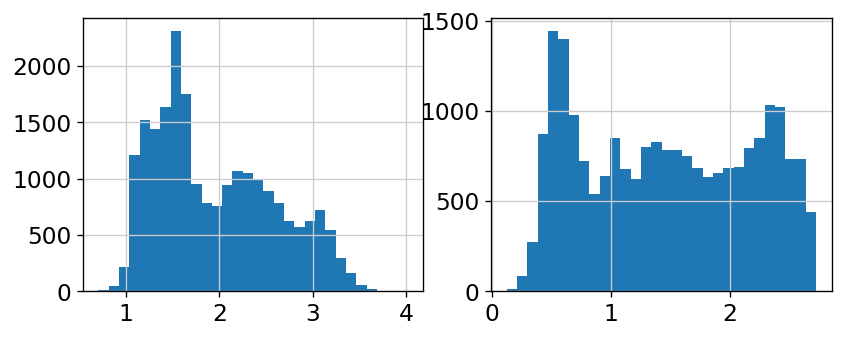

In [334]:
fig, axs = plt.subplots(1,2, figsize=(8,3), dpi=60)
axs[0].hist(syn_ad.obs['g_true'].values, bins=30);
axs[1].hist(syn_ad.obs['g_pred'].values, bins=30);

In [335]:
from scipy.stats import spearmanr, pearsonr

In [336]:
print(g_pred.max(), g_pred.min())
g_true.max(), g_true.min()

2.7289624 0.12727195


(4.015475, 0.7051047)

In [337]:
print(spearmanr(g_pred, g_true))
print(pearsonr(g_pred, g_true))

SignificanceResult(statistic=0.6581604652380387, pvalue=0.0)
PearsonRResult(statistic=0.6937011187699367, pvalue=0.0)


In [338]:
print("\ncorrelation of v : \n")
for i in range(5):
    print('dimension ',i)
    print(spearmanr(v_pred[:,i], v_true[:,i]))
    print(pearsonr(v_pred[:,i], v_true[:,i]))


correlation of v : 

dimension  0
SignificanceResult(statistic=0.7310528652349613, pvalue=0.0)
PearsonRResult(statistic=0.8116613207930873, pvalue=0.0)
dimension  1
SignificanceResult(statistic=0.8646701312857459, pvalue=0.0)
PearsonRResult(statistic=0.8378898668258767, pvalue=0.0)
dimension  2
SignificanceResult(statistic=0.7390293279164433, pvalue=0.0)
PearsonRResult(statistic=0.8356512173585854, pvalue=0.0)
dimension  3
SignificanceResult(statistic=0.9484145079833144, pvalue=0.0)
PearsonRResult(statistic=0.7910380978970805, pvalue=0.0)
dimension  4
SignificanceResult(statistic=0.7972985877611976, pvalue=0.0)
PearsonRResult(statistic=0.7790363769368979, pvalue=0.0)


In [339]:
import seaborn as sns

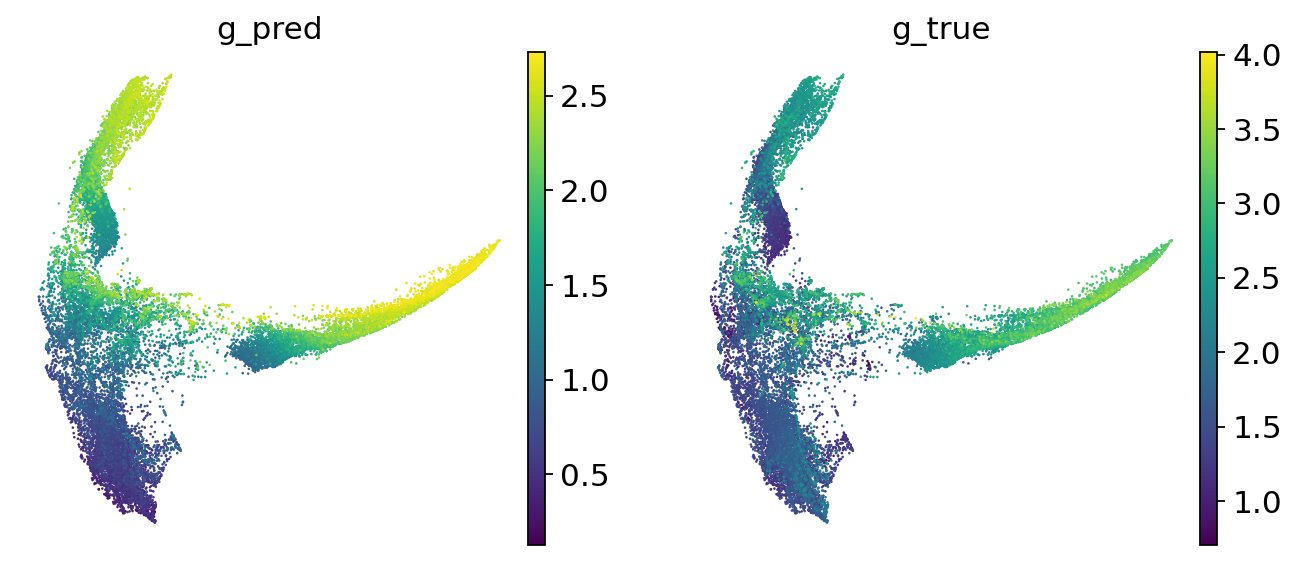

In [340]:
sc.pl.umap(syn_ad, color=['g_pred', 'g_true'])

Text(0, 0.5, 'D')

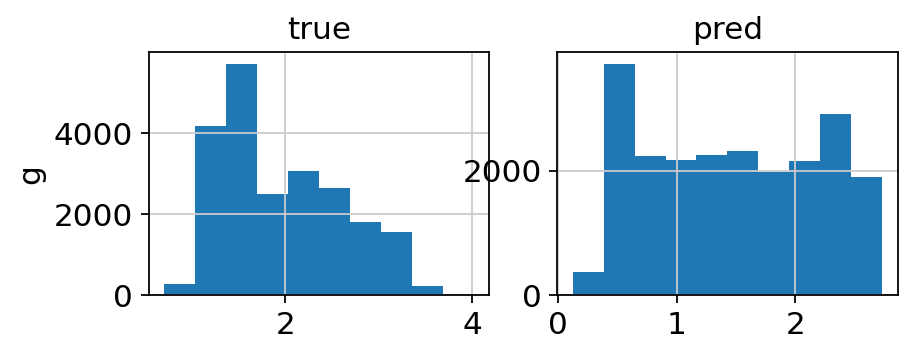

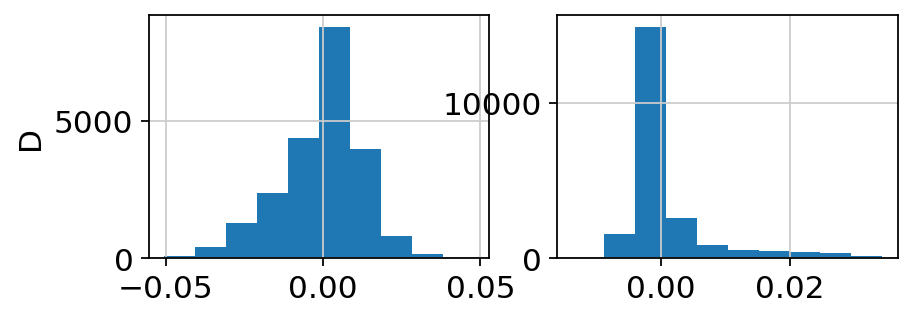

In [341]:
fig, axs = plt.subplots(1,2, figsize=(6,2))
axs[0].hist(g_true)
axs[1].hist(g_pred)
axs[0].set_ylabel('g')
axs[0].set_title('true')
axs[1].set_title('pred')


fig, axs = plt.subplots(1,2, figsize=(6,2))
axs[0].hist(D_true)
axs[1].hist(D_pred)
axs[0].set_ylabel('D')

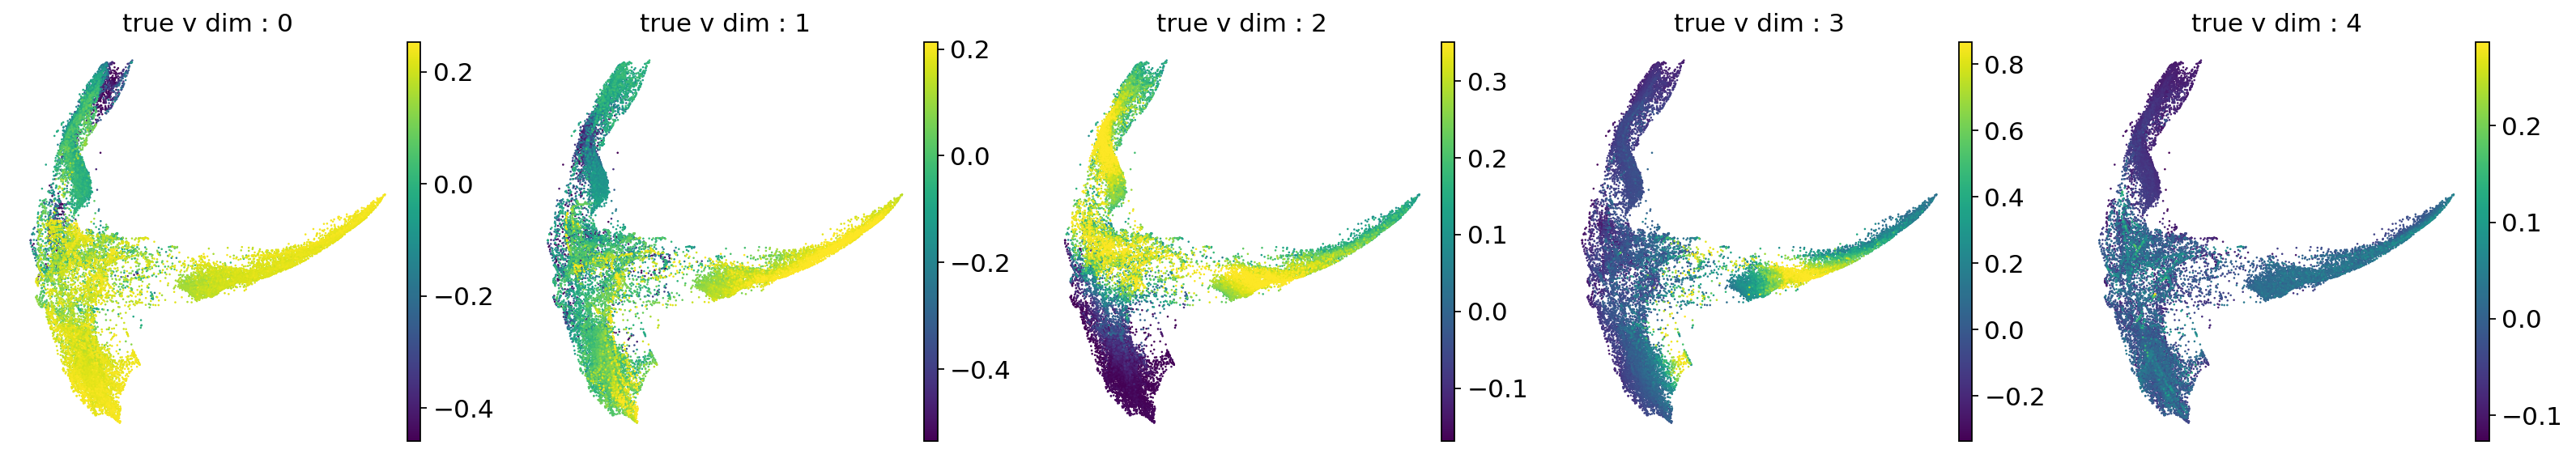

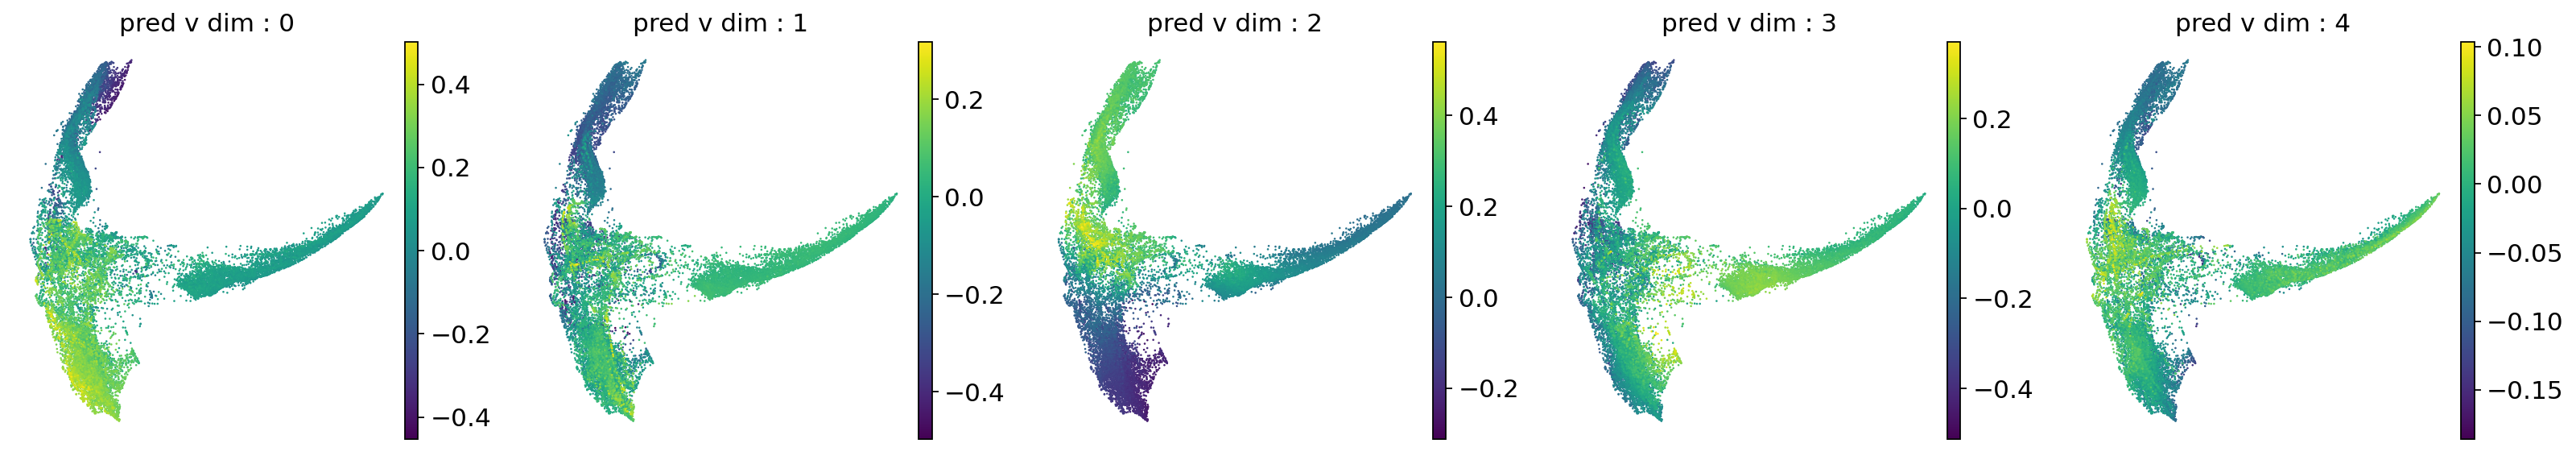

In [342]:
sc.pl.embedding(syn_ad, basis='X_phate', color=['DM_0', 'DM_1','DM_2', 'DM_3','DM_4'], layer='v_true', ncols=5, title=['true v dim : %s'%i for i in range(5)]);
sc.pl.embedding(syn_ad, basis='X_phate', color=['DM_0', 'DM_1','DM_2', 'DM_3','DM_4'], layer='v_pred', ncols=5, title=['pred v dim : %s'%i for i in range(5)]);

In [343]:
obs = syn_ad.obs.copy()

<Axes: xlabel='leiden_rs0.1', ylabel='growth rate'>

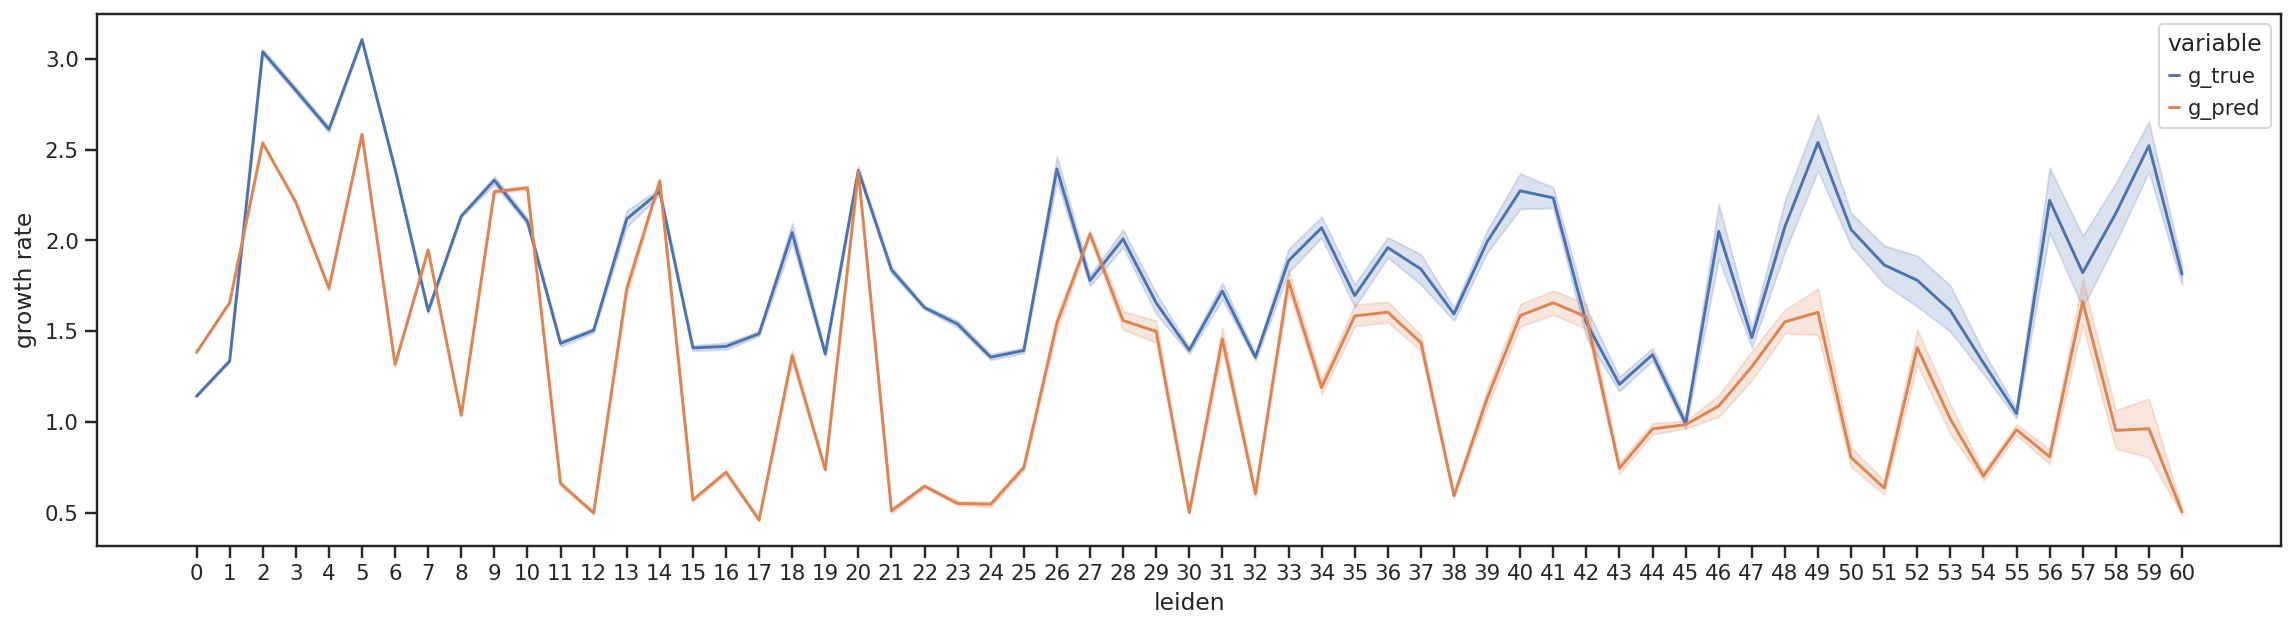

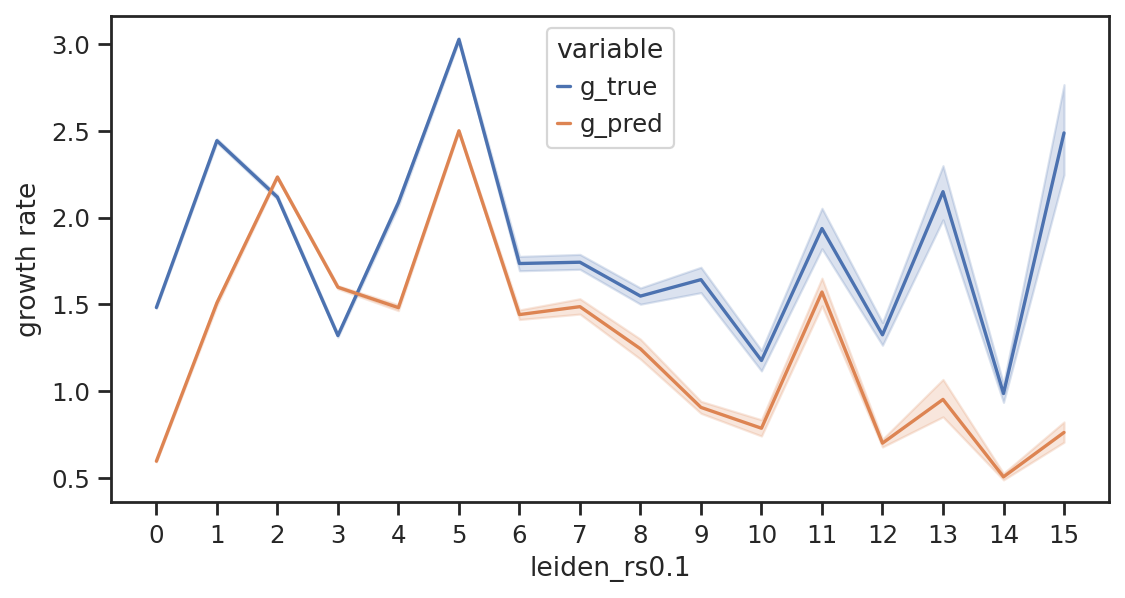

In [425]:
melt = obs[['leiden','g_true','g_pred']].melt(id_vars='leiden', value_name='growth rate')
fig=plt.figure(figsize=(20,5), dpi=70)
sns.lineplot(data=melt, x='leiden', y='growth rate', hue='variable', ax=fig.gca())#, width=0.5)

melt = obs[['leiden_rs0.1','g_true','g_pred']].melt(id_vars='leiden_rs0.1', value_name='growth rate')
fig=plt.figure(figsize=(8,4))
sns.lineplot(data=melt, x='leiden_rs0.1', y='growth rate', hue='variable', ax=fig.gca())#, width=0.5)



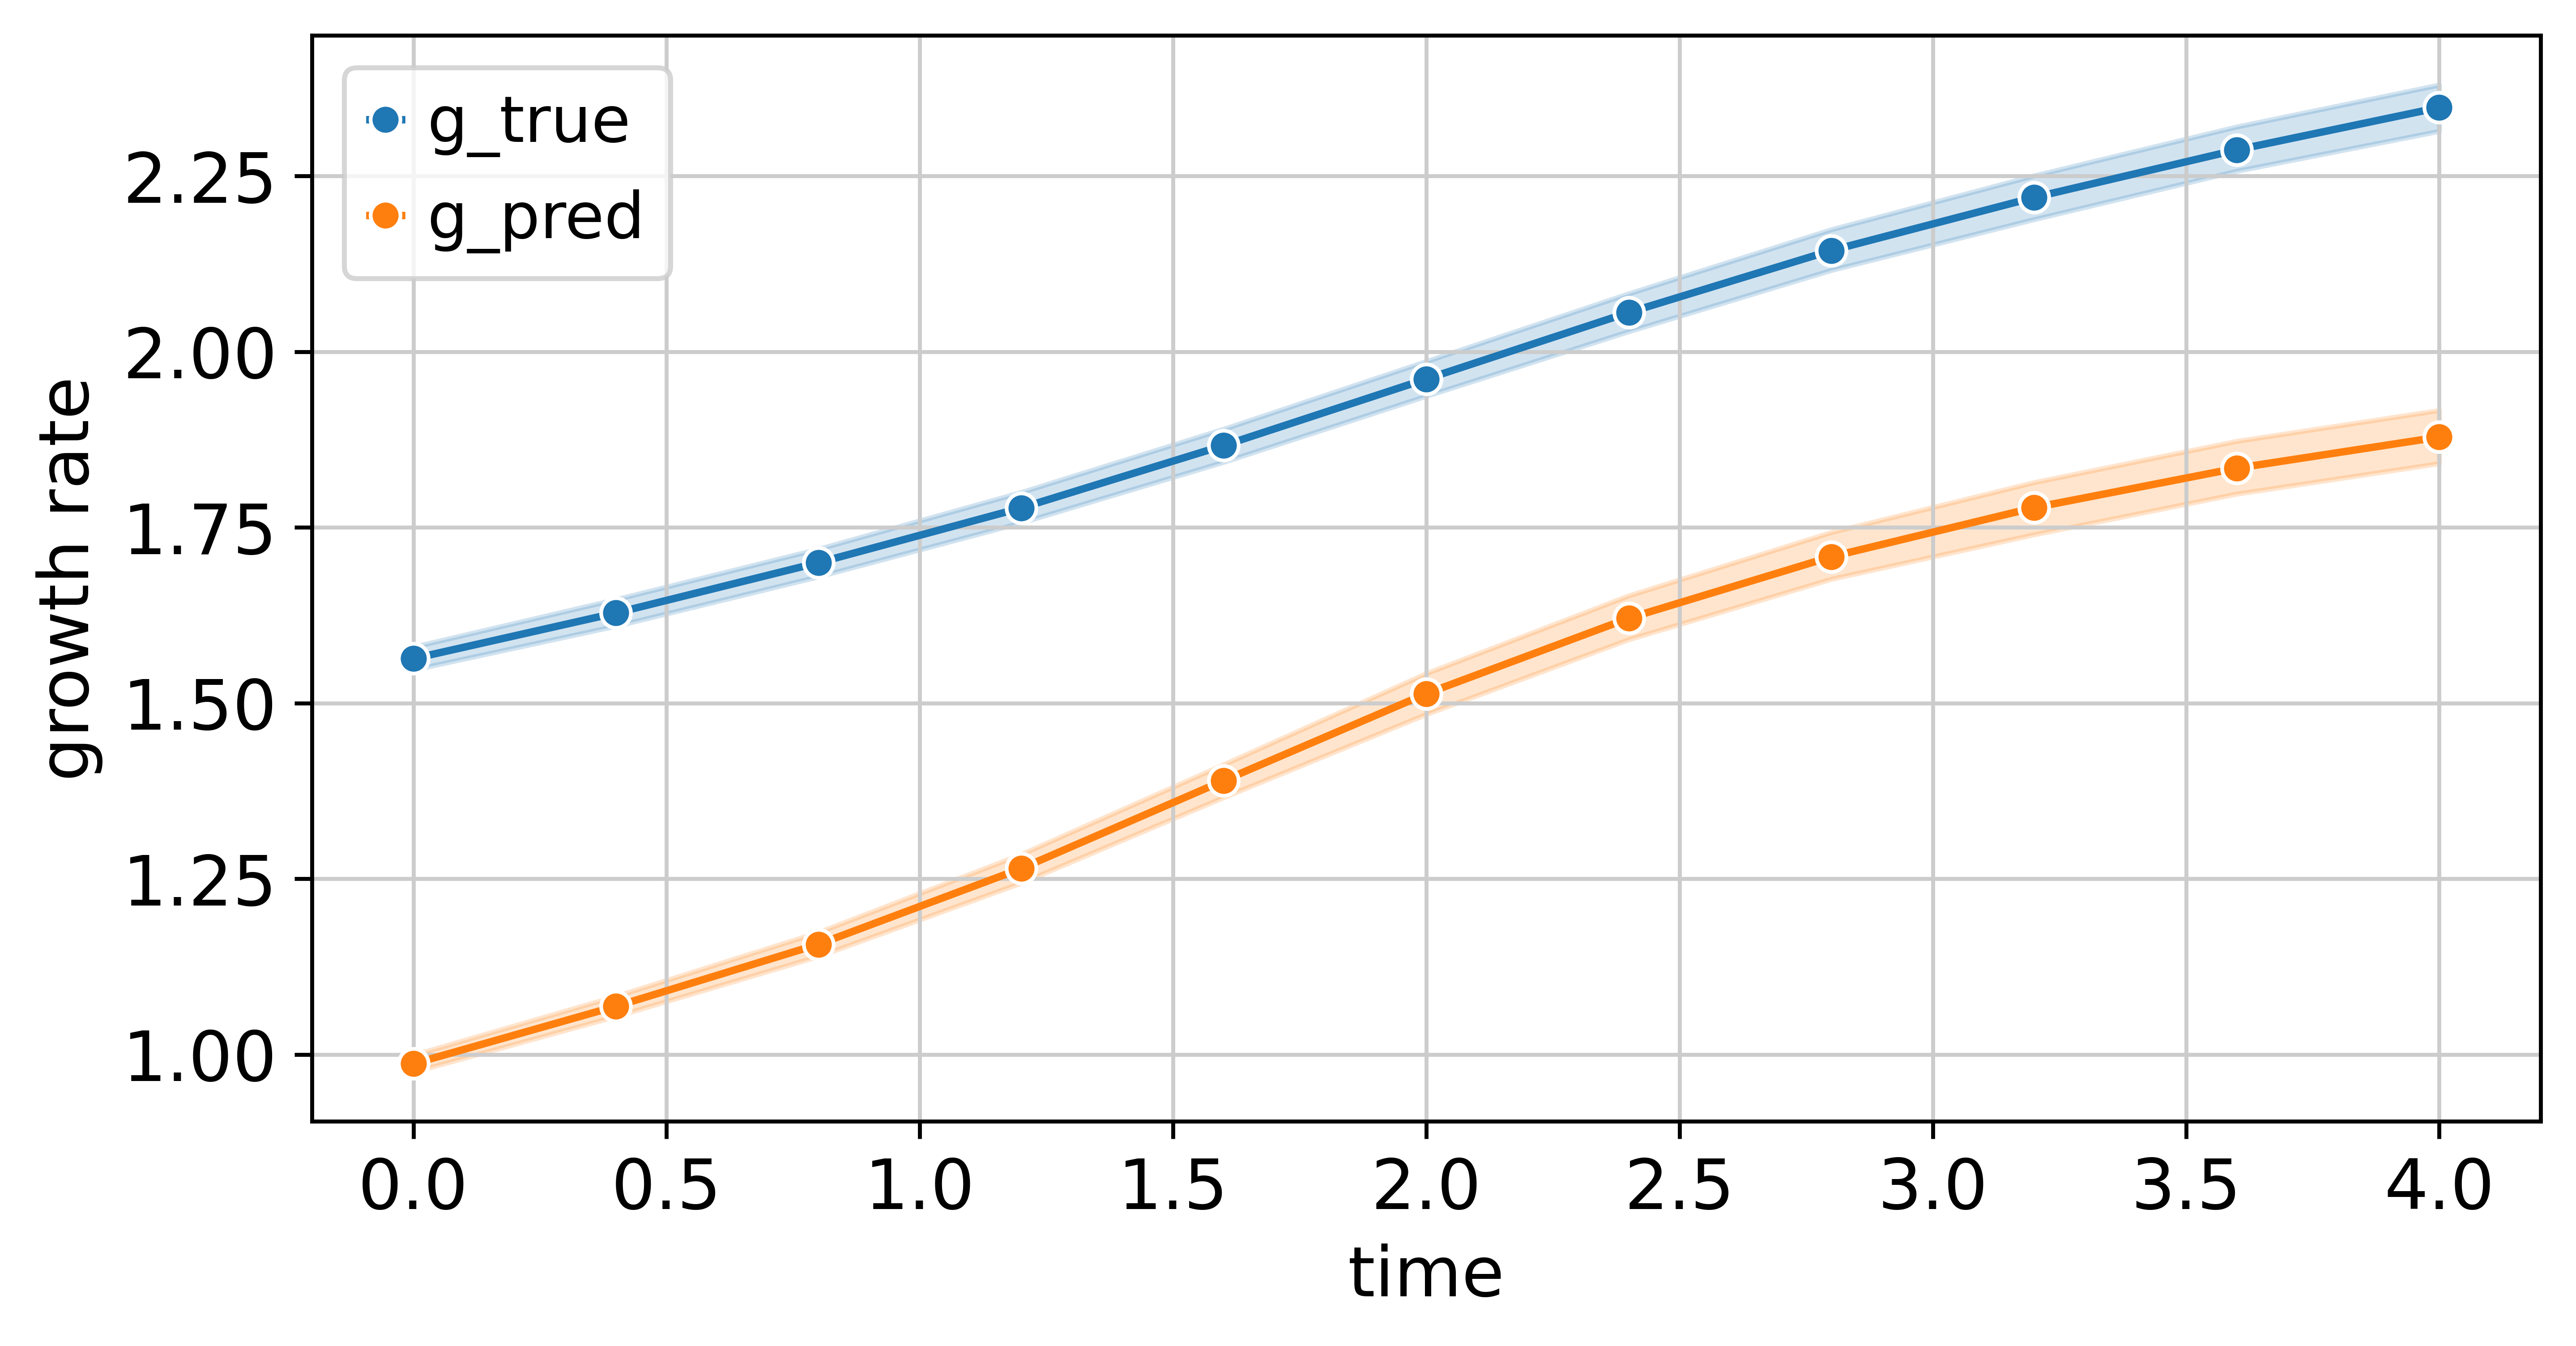

In [345]:
melt = obs[['time','g_true','g_pred']].melt(id_vars='time', value_name='growth rate')
fig=plt.figure(figsize=(8,4), dpi=399, frameon=False)
g_line = sns.lineplot(data=melt, x='time', y='growth rate', hue='variable', ax=fig.gca(), marker='o')
g_line.legend_.set_title('')

In [346]:
g_line.legend_.set_label(['true rate', 'predicted rate'])

In [347]:
'get_label', 'get_legend_handler'

('get_label', 'get_legend_handler')

In [348]:
g_line.legend_.texts

[Text(0, 0, 'g_true'), Text(0, 0, 'g_pred')]

In [349]:
dir(g_line.legend_)

['_PROPERTIES_EXCLUDED_FROM_SET',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_agg_filter',
 '_alignment',
 '_alpha',
 '_animated',
 '_auto_legend_data',
 '_axes',
 '_bbox_to_anchor',
 '_callbacks',
 '_clipon',
 '_clippath',
 '_cm_set',
 '_custom_handler_map',
 '_default_contains',
 '_default_handler_map',
 '_draggable',
 '_find_best_position',
 '_findoffset',
 '_fontsize',
 '_fully_clipped_to_axes',
 '_get_anchored_bbox',
 '_get_loc',
 '_gid',
 '_in_layout',
 '_init_legend_box',
 '_internal_update',
 '_label',
 '_legend_box',
 '_legend_handle_box',
 '_legend_title_box',
 '_loc',
 '_loc_real',
 '_loc_used_default',
 '_mode',
 '_mouseover',
 '_ncol

# short-term simulation of density

In [350]:
from PINN import reader

In [391]:
seen_timepoints = config['seen_timepoints']
leaveout_timepoints = config['leaveout_timepoints']
test_timepoints = config['test_timepoitns']

timepoint_label = np.array(['']*11, dtype=object)
timepoint_label[seen_timepoints] = 'train'
timepoint_label[leaveout_timepoints] = 'val'
timepoint_label[test_timepoints] = 'test'
print(timepoint_label)

print(seen_timepoints)
print(leaveout_timepoints) 
print(test_timepoints)

['train' 'train' 'train' 'val' 'train' 'test' 'train' 'val' 'train' 'test'
 'val']
[0, 1, 2, 4, 6, 8]
[3, 7, 10]
[5, 9]


In [352]:
syn_result_ckpt = torch.load("data/synthesized_data/5Dim_ncs_synparam_Jan23/syn_result_0-4.ckpt")


all_DS = reader.Syn_DS(cellstate=cellstate.numpy(), 
                  density=syn_result_ckpt['u_simulate'],
                  integrate_time= syn_result_ckpt['integrate_time'],
                  deltax=syn_result_ckpt['delta_x'],
                  batchsize = config['batchsize']
                  )

u_b = syn_result_ckpt['u_simulate'].numpy()

In [353]:
u_simulate = PINN.tl.density_shortterm_simulation(model, all_DS, 
                                     timepoints=integrate_time.numpy())
print(u_simulate.shape)

# insert initial condition
u_simulate = np.insert( u_simulate,0 , values=u_b[0], axis=0)
print(u_simulate.shape)

0it [00:00, ?it/s]

simulating from timepoint 0.0 to 0.4


simulating from timepoint 0.4 to 0.8
simulating from timepoint 0.8 to 1.2
simulating from timepoint 1.2 to 1.6
simulating from timepoint 1.6 to 2.0
simulating from timepoint 2.0 to 2.4
simulating from timepoint 2.4 to 2.8
simulating from timepoint 2.8 to 3.2
simulating from timepoint 3.2 to 3.6
simulating from timepoint 3.6 to 4.0
(10, 22000)
(11, 22000)


In [ ]:
from scipy.special import kl_div

In [396]:
base = 1e-30

ub_norm = u_b / u_b.sum(axis=1, keepdims=True)
usim_norm = u_simulate / u_simulate.sum(axis=1, keepdims=True)

log_ub = np.log(u_b+base)
log_usim = np.log(u_simulate+base)


klds = kl_div(ub_norm+base, usim_norm+base).sum(axis=1)
mse = np.power(ub_norm - usim_norm, 2).sum(axis=1) 
mse_by_ub = np.power(u_b - u_simulate, 2).sum(axis=1)  / u_b.sum(axis=1)**2

In [409]:
u_perform = pd.DataFrame({
    'kld' : klds, 'mse':mse, 'mse_ub': mse_by_ub, 'split':timepoint_label,
    'pop size' : np.log10(u_b.sum(axis=1)), 'pop size pred' : np.log10(u_simulate.sum(axis=1)),
    'time':np.around(integrate_time.numpy(),1)
})

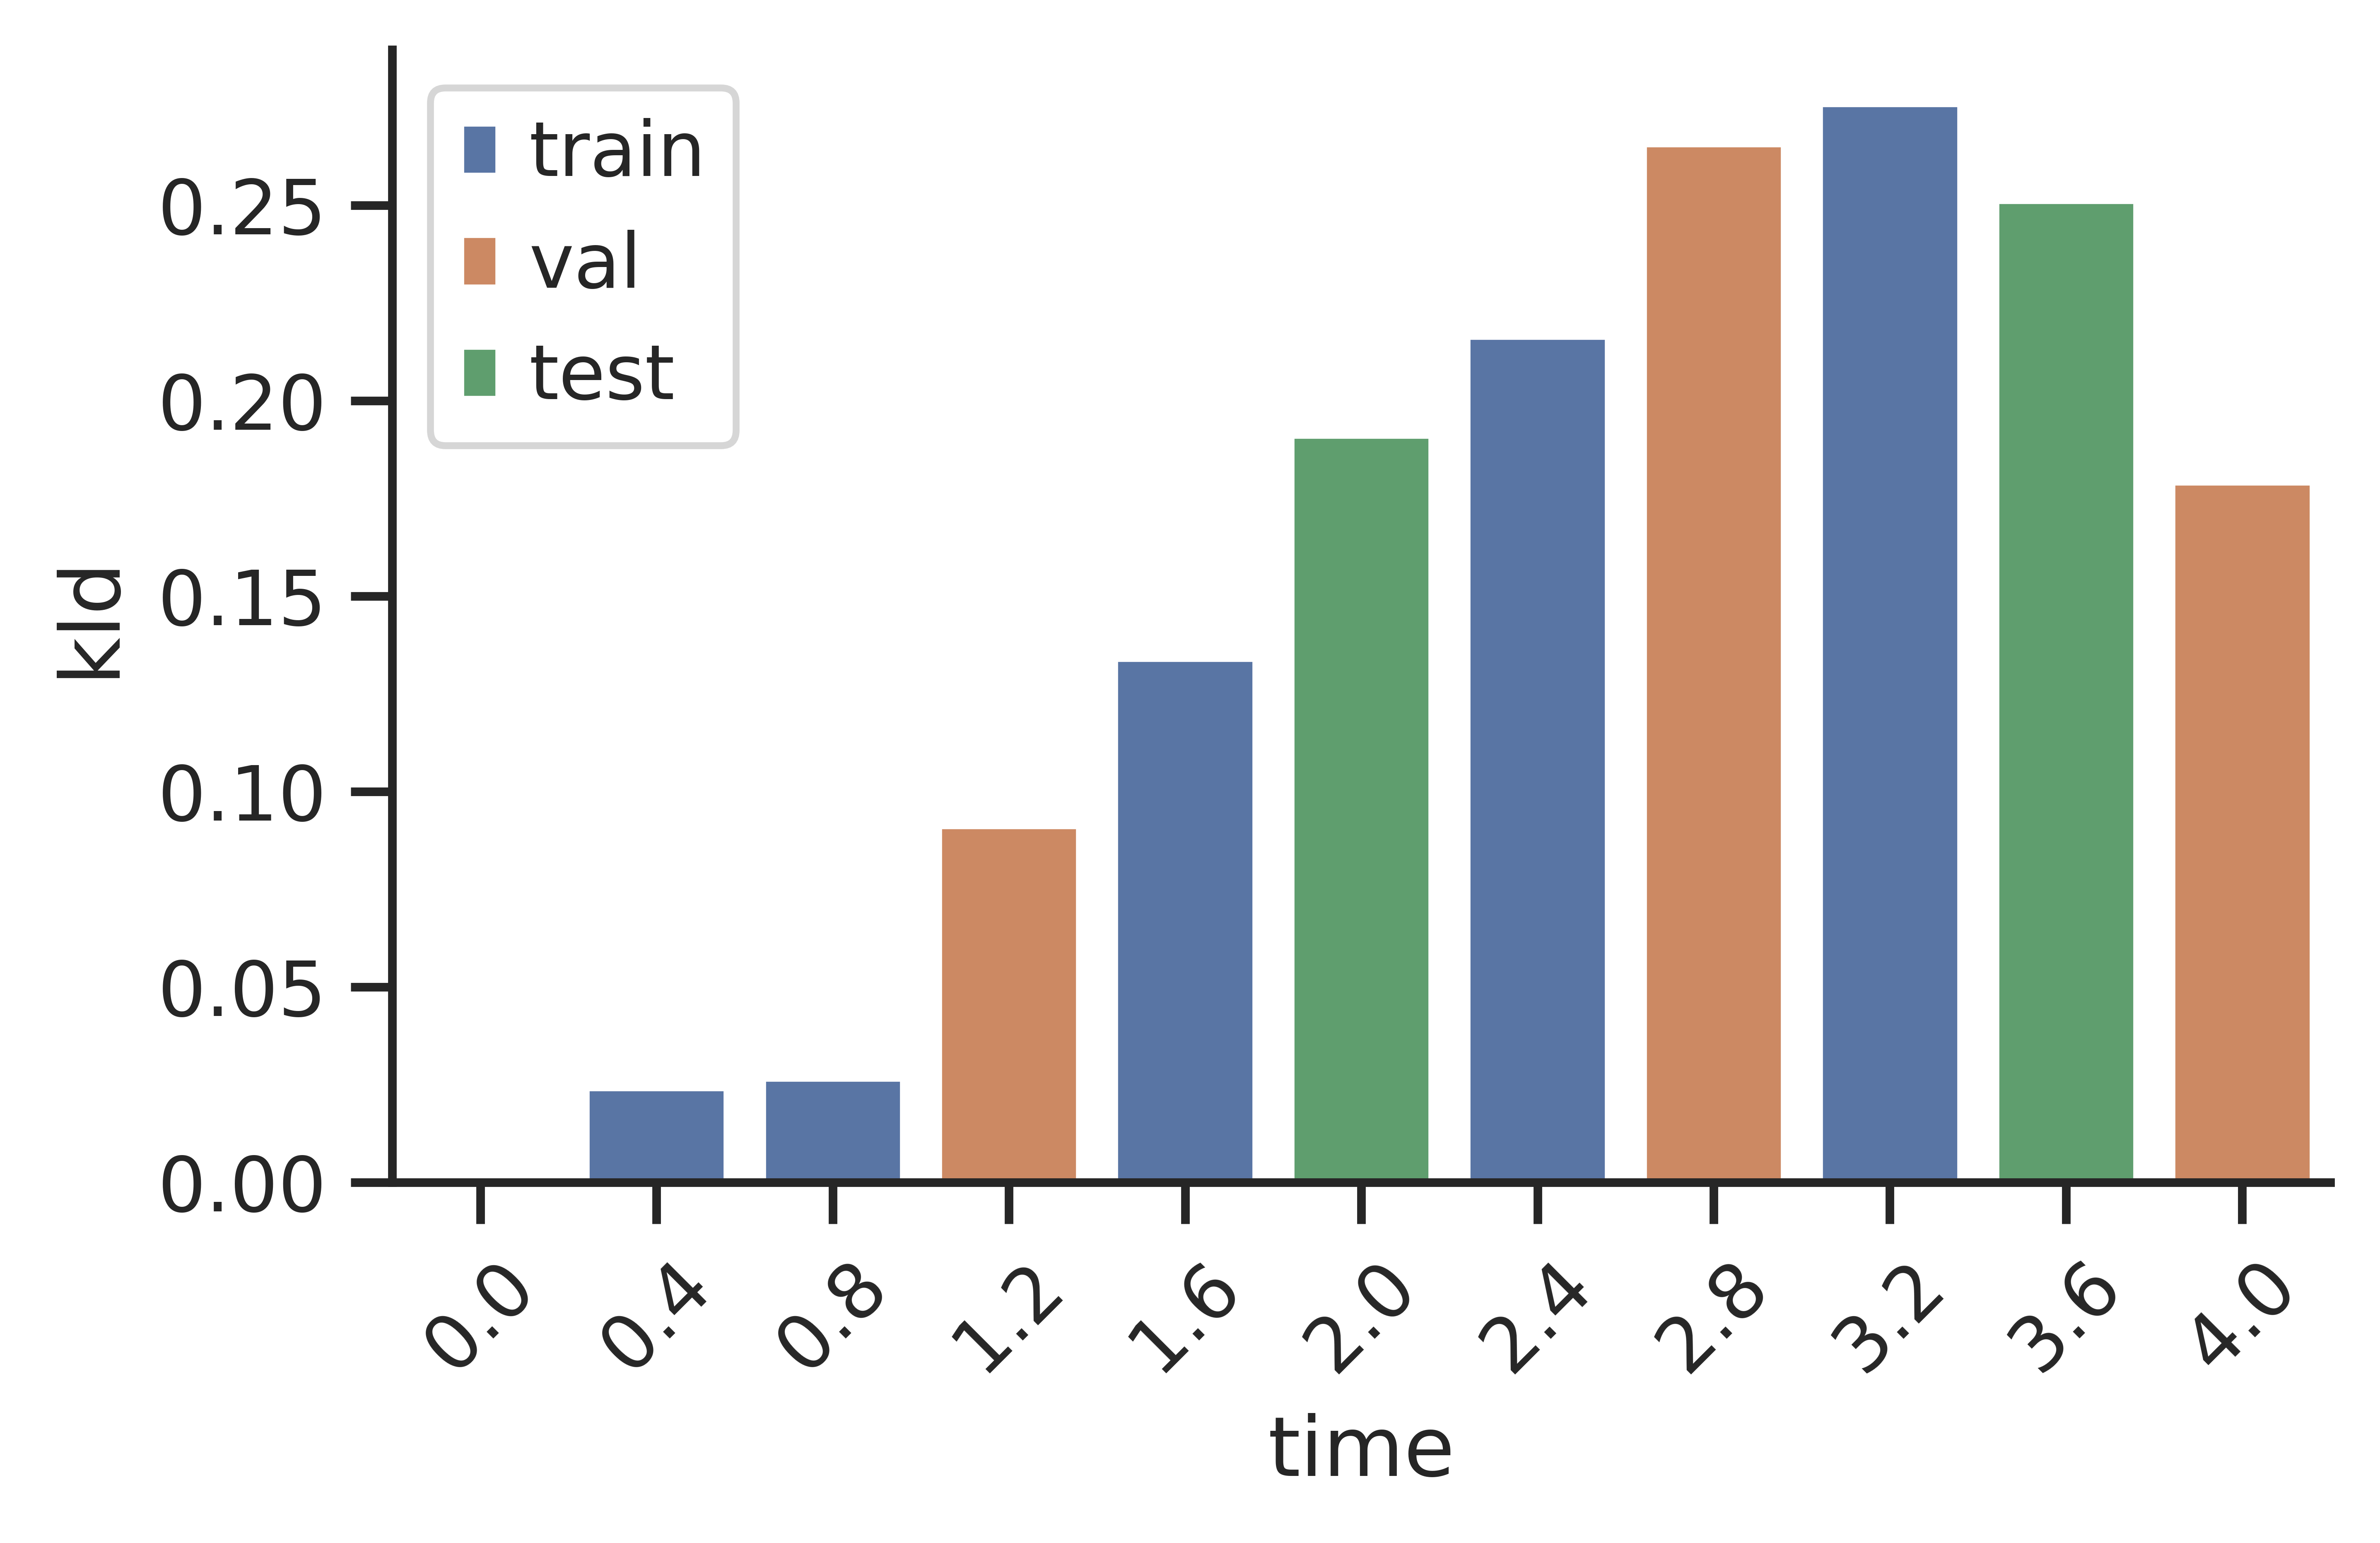

In [424]:
sns.set_theme(style='ticks', palette=None)
fig, ax = plt.subplots(1,1,figsize=(5,3), dpi=600)
sns.barplot(data=u_perform, x='time', y='kld', hue='split', legend='full', ax=ax)
ax.legend(title='')
plt.xticks(rotation=45)
sns.despine(ax=ax)

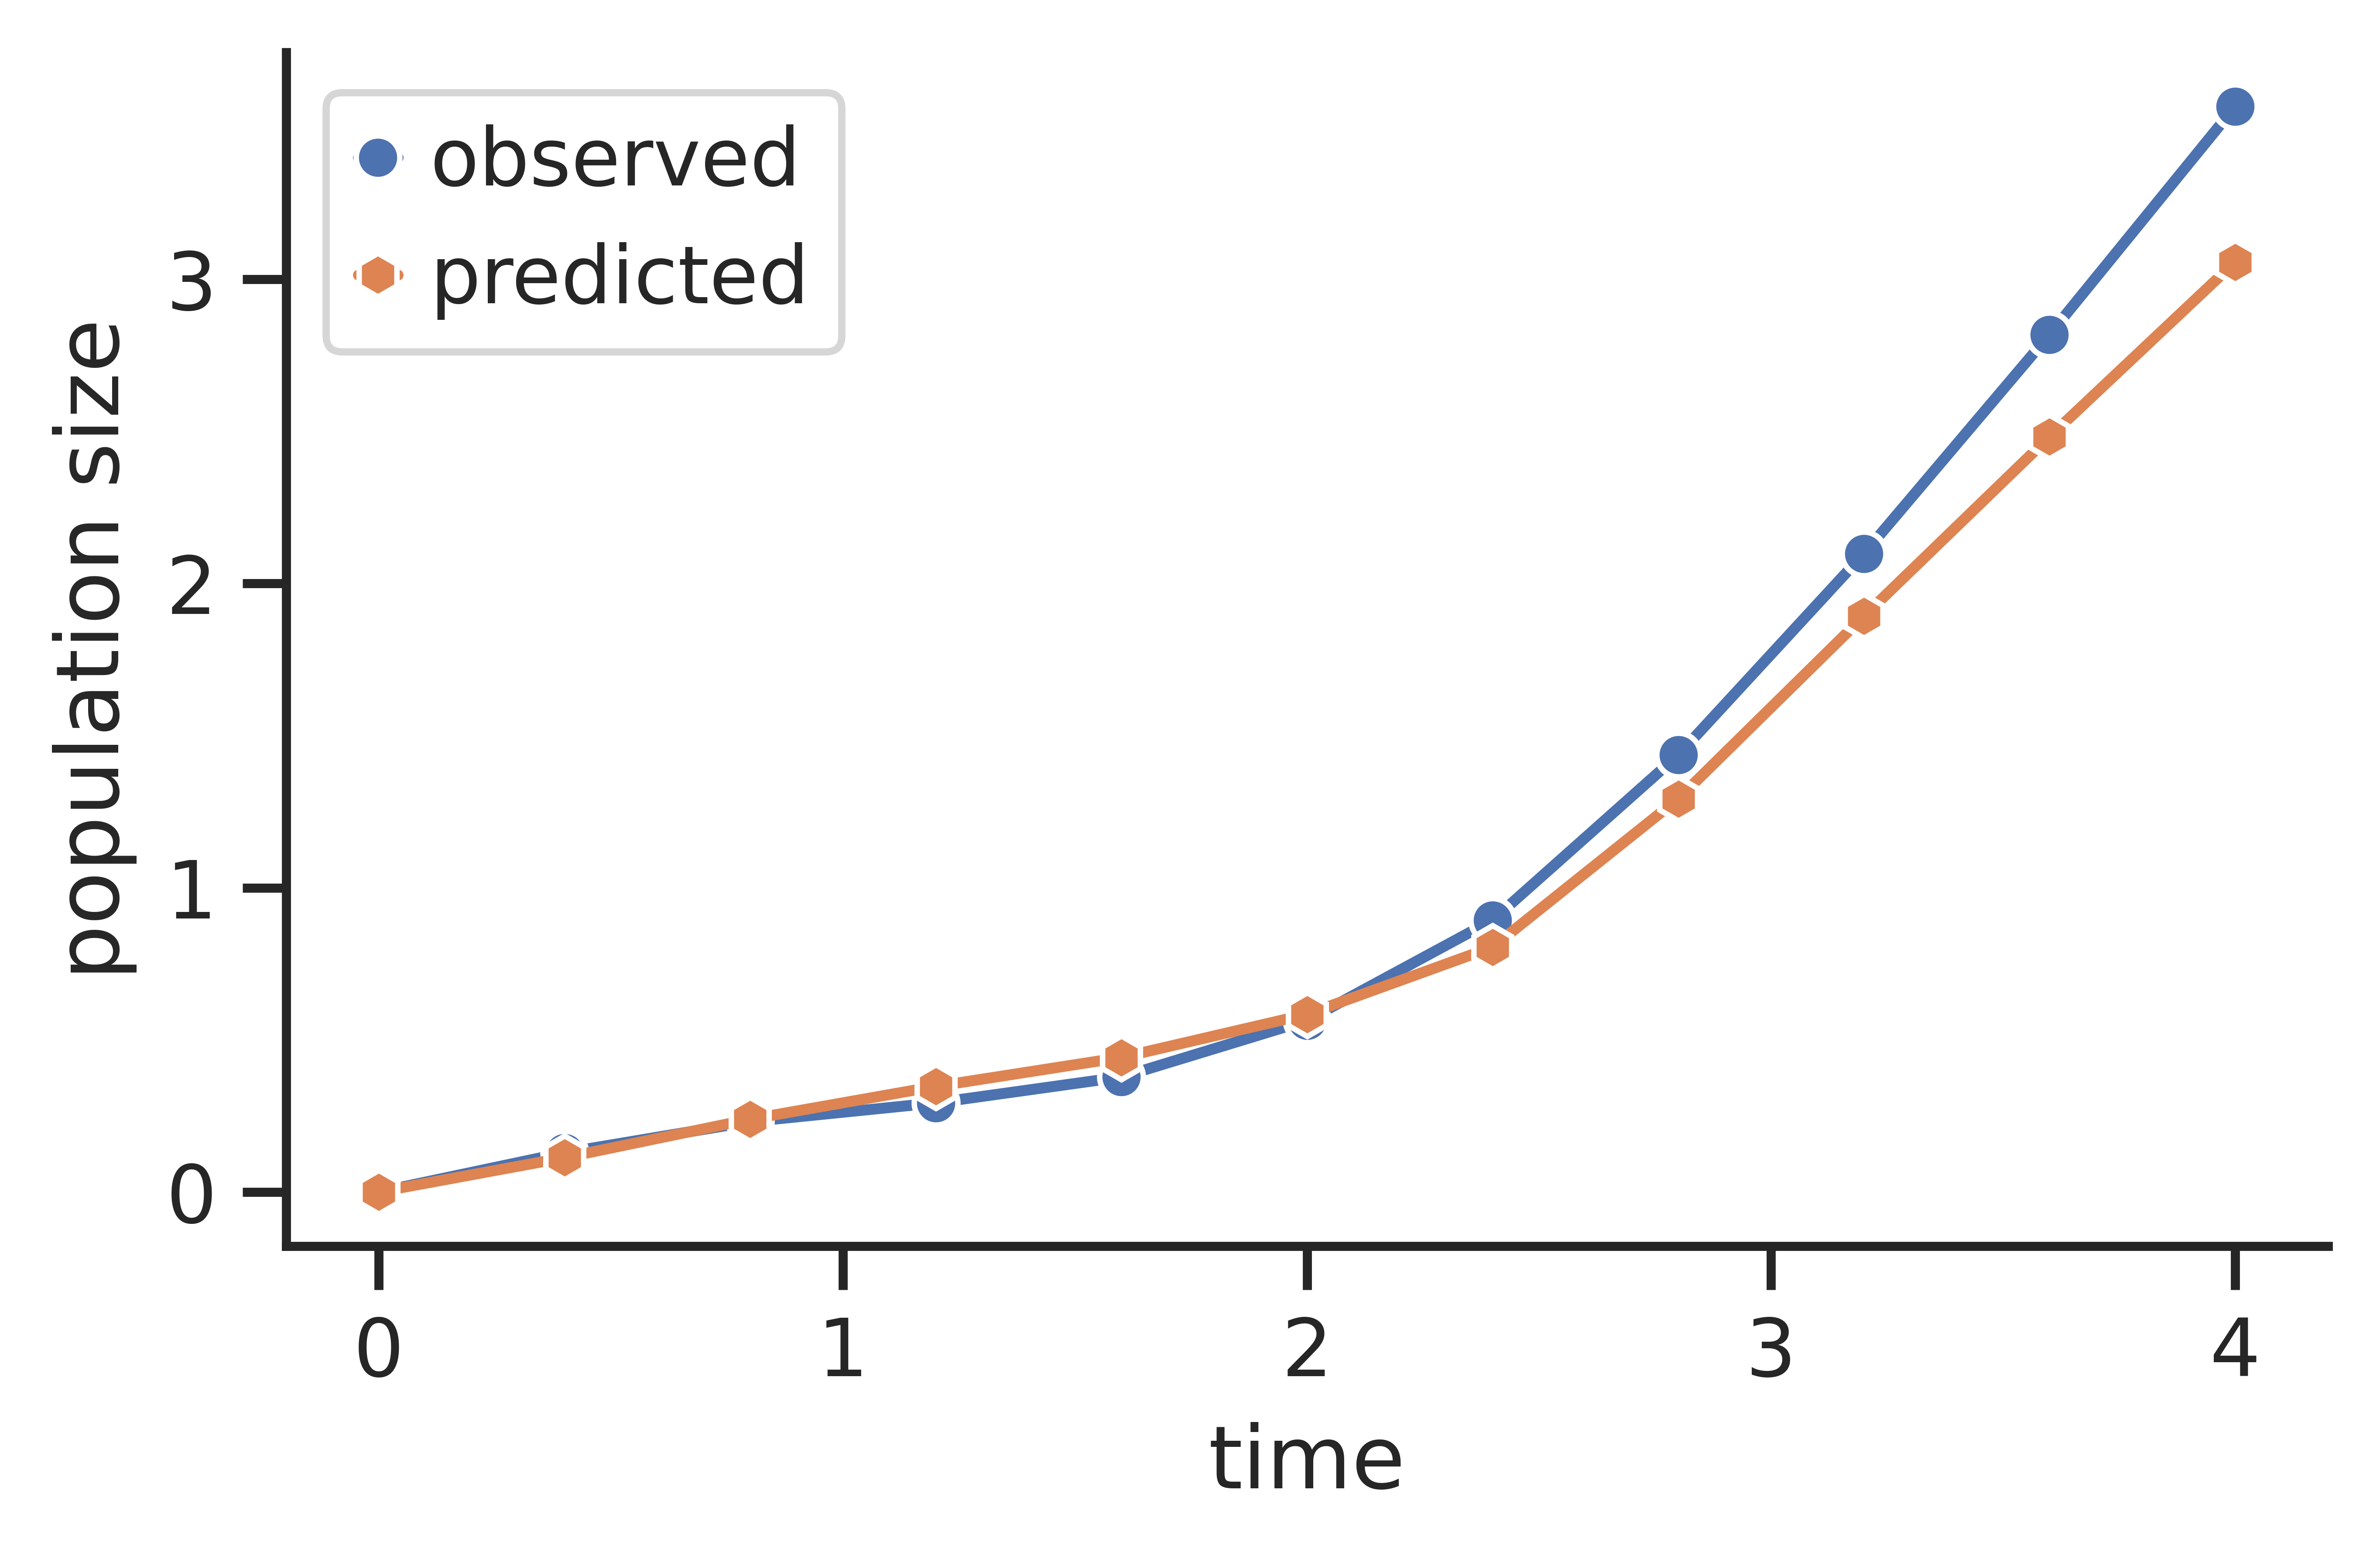

In [420]:
sns.set_theme(style='ticks', palette=None)
fig, ax = plt.subplots(1,1,figsize=(5,3), dpi=600)
sns.lineplot(data=u_perform, x='time', y='pop size', marker='o',  legend='full', ax=ax, label='observed')
sns.lineplot(data=u_perform, x='time', y='pop size pred', marker='h', legend='full', ax=ax,  label='predicted')
ax.legend(title='')
ax.set_ylabel('population size')
sns.despine(ax=ax)